## Analiza sentymentu tweetów przy pomocy RNN, BI-RNN, CNN oraz transformera distilbert-base-uncased


labele: negative, neutral, positive.


In [ ]:
import os
import re
import random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import optuna
from IPython.display import HTML, display

from captum.attr import LayerIntegratedGradients
from transformers import AutoTokenizer, DataCollatorWithPadding, AutoModelForSequenceClassification
from datasets import load_dataset
sns.set_theme(style="whitegrid")

In [7]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Load dataset

In [8]:
dataset = load_dataset("tweet_eval", "sentiment")
label_names = dataset["train"].features["label"].names
split_sizes = {split: len(dataset[split]) for split in dataset}
split_sizes

{'train': 45615, 'test': 12284, 'validation': 2000}

In [9]:
for i in range(3):
    item = dataset["train"][i]
    print(f"label={label_names[item['label']]} | text={item['text'][:120]}")

label=positive | text="QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
label=neutral | text="Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
label=neutral | text=Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow ni


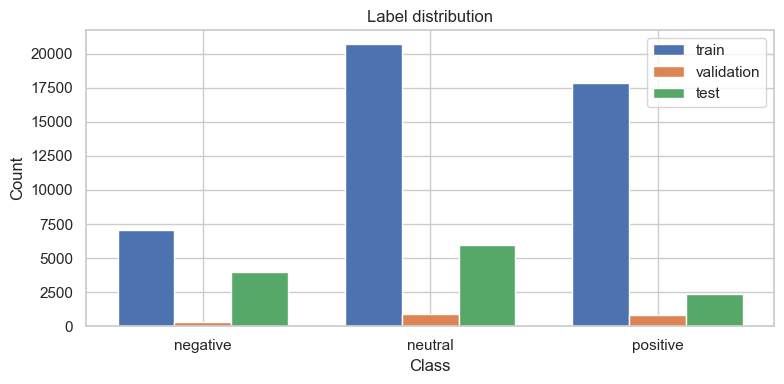

In [10]:
def label_distribution(ds):
    counts = Counter(ds["label"])
    return [counts[i] for i in range(len(label_names))]

train_counts = label_distribution(dataset["train"])
val_counts = label_distribution(dataset["validation"])
test_counts = label_distribution(dataset["test"])

x = np.arange(len(label_names))
width = 0.25

plt.figure(figsize=(8, 4))
plt.bar(x - width, train_counts, width, label="train")
plt.bar(x, val_counts, width, label="validation")
plt.bar(x + width, test_counts, width, label="test")
plt.xticks(x, label_names)
plt.title("Label distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

- Neutralnych jest najwiecej, potem pozytywne, a negatywne najmniej.
- Walidacja i test maja podobny rozklad do treningu, wiec split jest spojny.
- Lekka nierownowaga moze podbijac wyniki na klasie neutralnej - co zauważyłem przy obserwacji confusion matrix - szczególnie widoczne dla RNN i CNN, transformera jakby to nie dotyczyło. Wykonując zadanie jeszcze raz zaeksperymentowałbym z wyrównaniem datasetu

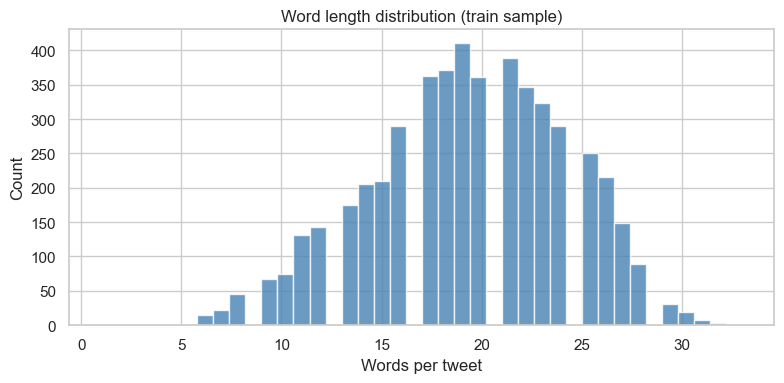

In [11]:
SAMPLE_FOR_EDA = 5000
eda_sample = dataset["train"].shuffle(seed=SEED).select(range(min(SAMPLE_FOR_EDA, len(dataset["train"]))))
word_lens = [len(t.split()) for t in eda_sample["text"]]

plt.figure(figsize=(8, 4))
plt.hist(word_lens, bins=40, color="steelblue", alpha=0.8)
plt.title("Word length distribution (train sample)")
plt.xlabel("Words per tweet")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

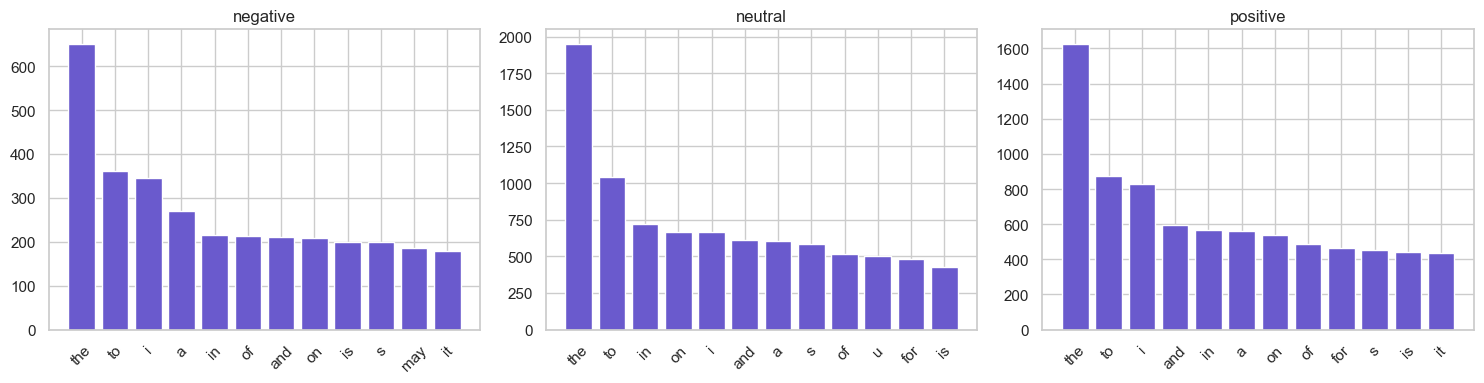

In [12]:
def simple_normalize(text):
    text = text.lower()
    text = re.sub("http[^ ]+", " ", text)
    text = re.sub("www[^ ]+", " ", text)
    text = re.sub("@[A-Za-z0-9_]+", " ", text)
    text = text.replace("#", " ")
    text = re.sub("[^a-z ]+", " ", text)
    text = re.sub(" +", " ", text).strip()
    return text

def top_tokens_by_label(ds, label_id, k=15):
    counter = Counter()
    for text, label in zip(ds["text"], ds["label"]):
        if label != label_id:
            continue
        tokens = simple_normalize(text).split()
        counter.update(tokens)
    return counter.most_common(k)

top_per_label = {label_names[i]: top_tokens_by_label(eda_sample, i, k=12) for i in range(len(label_names))}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, name in enumerate(label_names):
    items = top_per_label[name]
    tokens = [t for t, _ in items]
    counts = [c for _, c in items]
    axes[idx].bar(tokens, counts, color="slateblue")
    axes[idx].set_title(name)
    axes[idx].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

Najczestsze tokeny to słowa typu the, a , in itd wspolne dla wszystkich klas.
Na pierwszy rzut oka nie widać typowych słów sygnalizujących: good, bad, excellent
Wynika z tąd że użycie modeli sekwencyjnych i transformerów może być wskazane

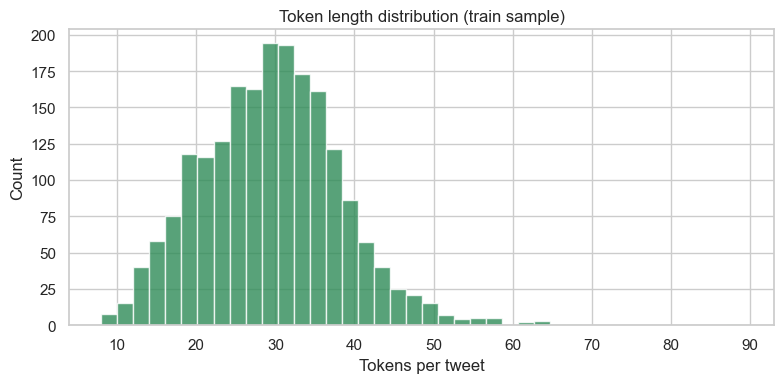

(45615, 2000, 12284)

In [13]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

tokenized = dataset.map(tokenize_batch, batched=True, remove_columns=["text"])
token_len_sample = tokenized["train"][: min(2000, len(tokenized["train"]))]["input_ids"]
token_lens = [len(ids) for ids in token_len_sample]

plt.figure(figsize=(8, 4))
plt.hist(token_lens, bins=40, color="seagreen", alpha=0.8)
plt.title("Token length distribution (train sample)")
plt.xlabel("Tokens per tweet")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch")

def maybe_subsample(ds, size):
    if size is None or size >= len(ds):
        return ds
    return ds.shuffle(seed=SEED).select(range(size))

TRAIN_SIZE = None
VAL_SIZE = None
TEST_SIZE = None

train_dataset = maybe_subsample(tokenized["train"], TRAIN_SIZE)
val_dataset = maybe_subsample(tokenized["validation"], VAL_SIZE)
test_dataset = maybe_subsample(tokenized["test"], TEST_SIZE)

len(train_dataset), len(val_dataset), len(test_dataset)


 Po tokenizacji wiekszość tweetów ma ok. 20-40 tokenow, dluższy ogon jest rzadki.
 Padding nie jest ekstremalny, co pomaga wydajności.

In [14]:
NUM_WORKERS = 0
BATCH_SIZE = 32
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=data_collator, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator, num_workers=NUM_WORKERS)

In [15]:
def confusion_matrix_counts(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def classification_metrics_from_cm(cm):
    tp = np.diag(cm).astype(float)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp

    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) != 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) != 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) != 0)

    macro_f1 = f1.mean() if len(f1) > 0 else 0.0
    accuracy = tp.sum() / cm.sum() if cm.sum() > 0 else 0.0
    return {"accuracy": accuracy, "macro_f1": macro_f1, "precision": precision, "recall": recall, "f1": f1}

## Definicje architektury

In [16]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, rnn_type="GRU", num_layers=1, bidirectional=False, dropout=0.2, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.rnn_type = rnn_type
        self.bidirectional = bidirectional
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        if rnn_type == "RNN":
            rnn_cls = nn.RNN
        elif rnn_type == "LSTM":
            rnn_cls = nn.LSTM
        elif rnn_type == "GRU":
            rnn_cls = nn.GRU
        else:
            raise ValueError(f"Unknown rnn_type: {rnn_type}")

        self.rnn = rnn_cls(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
        )
        self.dropout = nn.Dropout(dropout)
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.fc = nn.Linear(out_dim, num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)
        if attention_mask is not None:
            lengths = attention_mask.sum(dim=1).cpu()
            packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
            _, hidden = self.rnn(packed)
        else:
            _, hidden = self.rnn(x)

        if isinstance(hidden, tuple):
            hidden = hidden[0]

        if self.bidirectional:
            hidden = hidden.view(self.num_layers, 2, input_ids.size(0), self.hidden_dim)
            last = torch.cat([hidden[-1, 0], hidden[-1, 1]], dim=1)
        else:
            last = hidden[-1]
        return self.fc(self.dropout(last))

In [17]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, kernel_sizes, num_classes, dropout=0.3, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.convs = nn.ModuleList([nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)
        x = x.transpose(1, 2)
        convs = [F.relu(conv(x)) for conv in self.convs]
        pools = [F.max_pool1d(c, kernel_size=c.shape[2]).squeeze(2) for c in convs]
        out = torch.cat(pools, dim=1)
        out = self.dropout(out)
        return self.fc(out)

In [18]:
def forward_batch(model, batch, is_transformer=False):
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)
    if is_transformer:
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
    else:
        logits = model(input_ids, attention_mask=attention_mask)
    return logits, labels

def train_one_epoch(model, loader, optimizer, criterion, is_transformer=False):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in tqdm(loader, leave=False):
        optimizer.zero_grad()
        logits, labels = forward_batch(model, batch, is_transformer=is_transformer)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    avg_loss = total_loss / max(len(loader), 1)
    acc = correct / max(total, 1)
    return avg_loss, acc

def evaluate_simple(model, loader, criterion, is_transformer=False):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            logits, labels = forward_batch(model, batch, is_transformer=is_transformer)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    avg_loss = total_loss / max(len(loader), 1)
    acc = correct / max(total, 1)
    return avg_loss, acc

def fit_model(model, optimizer, criterion, train_loader, val_loader, epochs, model_name, is_transformer=False):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, is_transformer=is_transformer)
        val_loss, val_acc = evaluate_simple(model, val_loader, criterion, is_transformer=is_transformer)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"{model_name} | epoch {epoch}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    return history

def predict_all(model, loader, is_transformer=False):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for batch in loader:
            logits, labels = forward_batch(model, batch, is_transformer=is_transformer)
            preds = logits.argmax(dim=1)
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
    return y_true, y_pred

def evaluate_full(model, loader, num_classes, is_transformer=False):
    y_true, y_pred = predict_all(model, loader, is_transformer=is_transformer)
    cm = confusion_matrix_counts(y_true, y_pred, num_classes)
    metrics = classification_metrics_from_cm(cm)
    return metrics, cm

In [ ]:
NUM_CLASSES = len(label_names)
PAD_ID = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0

BASE_EMBED_DIM = 128
BASE_HIDDEN_DIM = 128
BASE_DROPOUT = 0.3
BASE_LR = 2e-3
BASE_EPOCHS = 3

base_models = {
    "RNN": RNNClassifier(
        vocab_size=tokenizer.vocab_size,
        embed_dim=BASE_EMBED_DIM,
        hidden_dim=BASE_HIDDEN_DIM,
        num_classes=NUM_CLASSES,
        rnn_type="RNN",
        dropout=BASE_DROPOUT,
        pad_id=PAD_ID,
    ),
    "LSTM": RNNClassifier(
        vocab_size=tokenizer.vocab_size,
        embed_dim=BASE_EMBED_DIM,
        hidden_dim=BASE_HIDDEN_DIM,
        num_classes=NUM_CLASSES,
        rnn_type="LSTM",
        dropout=BASE_DROPOUT,
        pad_id=PAD_ID,
    ),
    "GRU": RNNClassifier(
        vocab_size=tokenizer.vocab_size,
        embed_dim=BASE_EMBED_DIM,
        hidden_dim=BASE_HIDDEN_DIM,
        num_classes=NUM_CLASSES,
        rnn_type="GRU",
        dropout=BASE_DROPOUT,
        pad_id=PAD_ID,
    ),
    "TextCNN": TextCNN(
        vocab_size=tokenizer.vocab_size,
        embed_dim=BASE_EMBED_DIM,
        num_filters=128,
        kernel_sizes=(3, 4, 5),
        num_classes=NUM_CLASSES,
        dropout=BASE_DROPOUT,
        pad_id=PAD_ID,
    ),
}

base_histories = {}
criterion = nn.CrossEntropyLoss()

## Przeszukiwanie przy pomocy Optuna 

In [21]:
TRIAL_EPOCHS = 3
TRIAL_TRAIN_SIZE = 8000
TRIAL_VAL_SIZE = 2000

trial_train_dataset = maybe_subsample(tokenized["train"], TRIAL_TRAIN_SIZE)
trial_val_dataset = maybe_subsample(tokenized["validation"], TRIAL_VAL_SIZE)

trial_train_loader = DataLoader(trial_train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=data_collator, num_workers=NUM_WORKERS)
trial_val_loader = DataLoader(trial_val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=data_collator, num_workers=NUM_WORKERS)

def rnn_objective(trial):
    rnn_type = trial.suggest_categorical("rnn_type", ["RNN", "LSTM", "GRU"])
    embed_dim = trial.suggest_categorical("embed_dim", [64, 128, 256])
    hidden_dim = trial.suggest_int("hidden_dim", 64, 256, step=64)
    num_layers = trial.suggest_int("num_layers", 1, 2)
    bidirectional = trial.suggest_categorical("bidirectional", [False])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    model = RNNClassifier(
        vocab_size=tokenizer.vocab_size,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_classes=NUM_CLASSES,
        rnn_type=rnn_type,
        num_layers=num_layers,
        bidirectional=bidirectional,
        dropout=dropout,
        pad_id=PAD_ID,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(TRIAL_EPOCHS):
        train_one_epoch(model, trial_train_loader, optimizer, criterion, is_transformer=False)
        _, val_acc = evaluate_simple(model, trial_val_loader, criterion, is_transformer=False)
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_acc

def rnn_objective_bidirectional(trial):
    rnn_type = trial.suggest_categorical("rnn_type", ["RNN", "LSTM", "GRU"])
    embed_dim = trial.suggest_categorical("embed_dim", [64, 128, 256])
    hidden_dim = trial.suggest_int("hidden_dim", 64, 256, step=64)
    num_layers = trial.suggest_int("num_layers", 1, 2)
    bidirectional = trial.suggest_categorical("bidirectional", [True])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    model = RNNClassifier(
        vocab_size=tokenizer.vocab_size,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_classes=NUM_CLASSES,
        rnn_type=rnn_type,
        num_layers=num_layers,
        bidirectional=bidirectional,
        dropout=dropout,
        pad_id=PAD_ID,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(TRIAL_EPOCHS):
        train_one_epoch(model, trial_train_loader, optimizer, criterion, is_transformer=False)
        _, val_acc = evaluate_simple(model, trial_val_loader, criterion, is_transformer=False)
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_acc

def cnn_objective(trial):
    embed_dim = trial.suggest_categorical("embed_dim", [64, 128, 256])
    num_filters = trial.suggest_categorical("num_filters", [64, 128, 256])
    kernel_sizes = trial.suggest_categorical("kernel_sizes", [(2, 3, 4), (3, 4, 5), (3, 5, 7)])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    model = TextCNN(
        vocab_size=tokenizer.vocab_size,
        embed_dim=embed_dim,
        num_filters=num_filters,
        kernel_sizes=kernel_sizes,
        num_classes=NUM_CLASSES,
        dropout=dropout,
        pad_id=PAD_ID,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(TRIAL_EPOCHS):
        train_one_epoch(model, trial_train_loader, optimizer, criterion, is_transformer=False)
        _, val_acc = evaluate_simple(model, trial_val_loader, criterion, is_transformer=False)
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_acc

study_rnn = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.HyperbandPruner(),
)
study_rnn_bidirectional = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.HyperbandPruner(),
)
study_cnn = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.HyperbandPruner(),
)

study_rnn.optimize(rnn_objective, n_trials=15)
study_rnn_bidirectional.optimize(rnn_objective_bidirectional, n_trials=15)
study_cnn.optimize(cnn_objective, n_trials=15)

print("Best RNN (uni) params:", study_rnn.best_params)
print("Best RNN (bi) params:", study_rnn_bidirectional.best_params)
print("Best CNN params:", study_cnn.best_params)

[I 2026-05-11 22:58:50,011] A new study created in memory with name: no-name-e8b29833-a099-41b4-8d43-60501733ce2f
[I 2026-05-11 22:58:50,013] A new study created in memory with name: no-name-517e1c7f-23ad-427a-bf1b-db7f1eeae8a4
[I 2026-05-11 22:58:50,015] A new study created in memory with name: no-name-8af99168-048c-4edf-b812-96b8dd97e419
[I 2026-05-11 22:59:30,144] Trial 0 finished with value: 0.5635 and parameters: {'rnn_type': 'LSTM', 'embed_dim': 64, 'hidden_dim': 64, 'num_layers': 2, 'bidirectional': False, 'dropout': 0.34044600469728353, 'lr': 0.0015958573588141277}. Best is trial 0 with value: 0.5635.
[I 2026-05-11 23:00:21,924] Trial 1 finished with value: 0.5495 and parameters: {'rnn_type': 'LSTM', 'embed_dim': 64, 'hidden_dim': 128, 'num_layers': 2, 'bidirectional': False, 'dropout': 0.2727780074568463, 'lr': 0.0003124565071260876}. Best is trial 0 with value: 0.5635.
[I 2026-05-11 23:00:57,322] Trial 2 finished with value: 0.4695 and parameters: {'rnn_type': 'RNN', 'embed_d

Best RNN (uni) params: {'rnn_type': 'GRU', 'embed_dim': 256, 'hidden_dim': 256, 'num_layers': 2, 'bidirectional': False, 'dropout': 0.1958117721564353, 'lr': 0.002194309355738222}
Best RNN (bi) params: {'rnn_type': 'GRU', 'embed_dim': 256, 'hidden_dim': 64, 'num_layers': 2, 'bidirectional': True, 'dropout': 0.12982025747190834, 'lr': 0.0047499747713783975}
Best CNN params: {'embed_dim': 128, 'num_filters': 64, 'kernel_sizes': (2, 3, 4), 'dropout': 0.3113831721811223, 'lr': 0.0016241339492548278}


## Dotrenowanie najlepszych modeli

In [22]:
FINAL_EPOCHS_RNN = 12
FINAL_EPOCHS_CNN = 12

def build_rnn_from_params(params):
    return RNNClassifier(
        vocab_size=tokenizer.vocab_size,
        embed_dim=params["embed_dim"],
        
        hidden_dim=params["hidden_dim"],
        num_classes=NUM_CLASSES,
        rnn_type=params["rnn_type"],
        num_layers=params["num_layers"],
        bidirectional=params["bidirectional"],
        dropout=params["dropout"],
        pad_id=PAD_ID,
    )

def build_cnn_from_params(params):
    return TextCNN(
        vocab_size=tokenizer.vocab_size,
        embed_dim=params["embed_dim"],
        num_filters=params["num_filters"],
        kernel_sizes=params["kernel_sizes"],
        num_classes=NUM_CLASSES,
        dropout=params["dropout"],
        pad_id=PAD_ID,
    )

best_rnn_model = build_rnn_from_params(study_rnn.best_params).to(device)
best_rnn_bi_model = build_rnn_from_params(study_rnn_bidirectional.best_params).to(device)
best_cnn_model = build_cnn_from_params(study_cnn.best_params).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_rnn = optim.AdamW(best_rnn_model.parameters(), lr=study_rnn.best_params["lr"])
optimizer_rnn_bi = optim.AdamW(best_rnn_bi_model.parameters(), lr=study_rnn_bidirectional.best_params["lr"])
optimizer_cnn = optim.AdamW(best_cnn_model.parameters(), lr=study_cnn.best_params["lr"])

history_best_rnn = fit_model(best_rnn_model, optimizer_rnn, criterion, train_loader, val_loader, FINAL_EPOCHS_RNN, model_name="Best RNN (Uni)", is_transformer=False)
history_best_rnn_bi = fit_model(best_rnn_bi_model, optimizer_rnn_bi, criterion, train_loader, val_loader, FINAL_EPOCHS_RNN, model_name="Best RNN (Bi)", is_transformer=False)
history_best_cnn = fit_model(best_cnn_model, optimizer_cnn, criterion, train_loader, val_loader, FINAL_EPOCHS_CNN, model_name="Best CNN", is_transformer=False)

Best RNN (Uni) | epoch 1/12 | train_loss=0.8221 train_acc=0.6179 val_loss=0.7356 val_acc=0.6775


Best RNN (Uni) | epoch 2/12 | train_loss=0.6441 train_acc=0.7156 val_loss=0.7250 val_acc=0.6780


Best RNN (Uni) | epoch 3/12 | train_loss=0.5072 train_acc=0.7869 val_loss=0.7279 val_acc=0.6895


Best RNN (Uni) | epoch 4/12 | train_loss=0.3903 train_acc=0.8441 val_loss=0.8022 val_acc=0.6715


Best RNN (Uni) | epoch 5/12 | train_loss=0.3066 train_acc=0.8810 val_loss=0.9521 val_acc=0.6570


...

Best CNN | epoch 8/12 | train_loss=0.2682 train_acc=0.8968 val_loss=1.3675 val_acc=0.6400


Best CNN | epoch 9/12 | train_loss=0.2226 train_acc=0.9163 val_loss=1.5044 val_acc=0.6450


Best CNN | epoch 10/12 | train_loss=0.1894 train_acc=0.9286 val_loss=1.6994 val_acc=0.6410


Best CNN | epoch 11/12 | train_loss=0.1643 train_acc=0.9403 val_loss=1.8186 val_acc=0.6360


Best CNN | epoch 12/12 | train_loss=0.1483 train_acc=0.9471 val_loss=2.0347 val_acc=0.6290


## Transformer fine-tuning

In [24]:
TRANSFORMER_EPOCHS = 3
TRANSFORMER_LR = 2e-5
FREEZE_TRANSFORMER = False

bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_CLASSES).to(device)

if FREEZE_TRANSFORMER:
    for param in bert_model.base_model.parameters():
        param.requires_grad = False

optimizer_bert = optim.AdamW(bert_model.parameters(), lr=TRANSFORMER_LR)
criterion = nn.CrossEntropyLoss()

history_bert = fit_model(bert_model, optimizer_bert, criterion, train_loader, val_loader, TRANSFORMER_EPOCHS, model_name="Transformer", is_transformer=True)

c:\Users\wolny\Documents\projects\agh\6sem\GNN\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\wolny\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10069.39it/s]
[transformers] DistilBe

Transformer | epoch 1/3 | train_loss=0.6737 train_acc=0.6914 val_loss=0.6142 val_acc=0.7320


Transformer | epoch 2/3 | train_loss=0.5168 train_acc=0.7740 val_loss=0.6215 val_acc=0.7300


Transformer | epoch 3/3 | train_loss=0.3788 train_acc=0.8437 val_loss=0.6898 val_acc=0.7345


## Porównanie

In [36]:
models_to_eval = {
    "Best RNN (Uni)": (best_rnn_model, False),
    "Best RNN (Bi)": (best_rnn_bi_model, False),
    "Best CNN": (best_cnn_model, False),
    "Transformer": (bert_model, True),
}

results = []
cms = {}

for name, (model, is_transformer) in models_to_eval.items():
    metrics, cm = evaluate_full(model, test_loader, NUM_CLASSES, is_transformer=is_transformer)
    results.append((name, metrics))
    cms[name] = cm

def print_metrics_table(results):
    header = f"{'model':<15} {'acc':>8} {'macro_f1':>10}"
    print(header)
    print("-" * len(header))
    for name, metrics in results:
        print(f"{name:<15} {metrics['accuracy']*100:>7.2f} {metrics['macro_f1']*100:>9.2f}")

print_metrics_table(results)



model                acc   macro_f1
-----------------------------------
Best RNN (Uni)    56.03     54.61
Best RNN (Bi)     55.64     54.28
Best CNN          55.01     53.39
Transformer       67.48     67.28


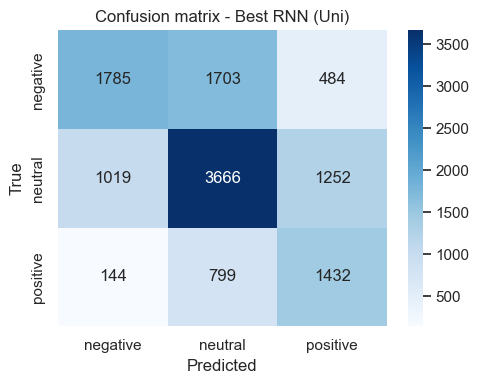

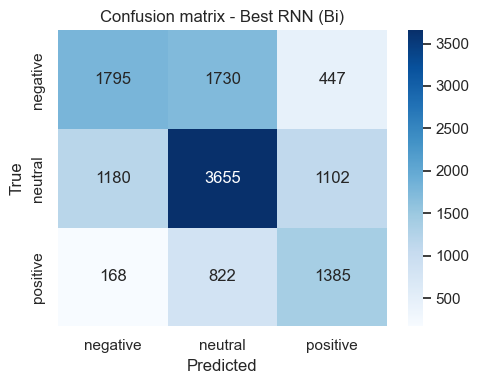

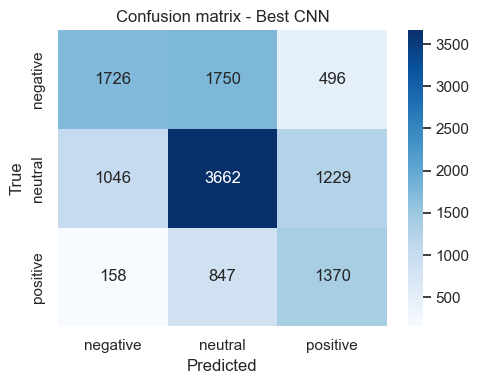

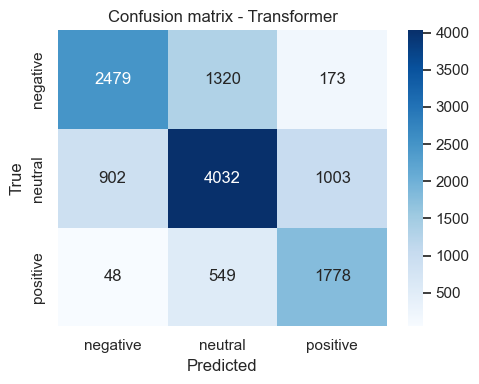

In [26]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

for name, cm in cms.items():
    plot_confusion_matrix(cm, f"Confusion matrix - {name}")

Klasyczne modele w porównaniu do transformera czesciej "sciagaja" negatywne predykcje do neutralnej.

## Explainability with Captum

In [27]:
def get_embedding_layer(model, is_transformer):
    if is_transformer:
        return model.get_input_embeddings()
    return model.embedding

def forward_for_captum(model, input_ids, attention_mask, is_transformer):
    if is_transformer:
        return model(input_ids=input_ids, attention_mask=attention_mask).logits
    return model(input_ids, attention_mask=attention_mask)

def merge_tokens_and_scores(tokens, scores):
    merged_tokens = []
    merged_scores = []
    for tok, score in zip(tokens, scores):
        if tok.startswith("##") and merged_tokens:
            merged_tokens[-1] = merged_tokens[-1] + tok[2:]
            merged_scores[-1] = merged_scores[-1] + score
        else:
            merged_tokens.append(tok)
            merged_scores.append(score)
    return merged_tokens, np.array(merged_scores)

def render_attributions(tokens, scores):
    max_val = np.max(np.abs(scores)) + 1e-8
    html_tokens = []
    for tok, score in zip(tokens, scores):
        norm = score / max_val
        if norm >= 0:
            color = f"rgba(255, 0, 0, {abs(norm):.3f})"
        else:
            color = f"rgba(0, 0, 255, {abs(norm):.3f})"
        html_tokens.append(f"<span style='background-color:{color}; padding:2px; margin:1px; border-radius:3px'>{tok}</span>")
    return HTML(" ".join(html_tokens))

def attribute_text(model, text, is_transformer=False, target_label=None):
    model.eval()
    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LEN)
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    logits = forward_for_captum(model, input_ids, attention_mask, is_transformer)
    probs = F.softmax(logits, dim=1).detach().cpu().numpy()[0]
    pred = int(np.argmax(probs)) if target_label is None else target_label

    embedding_layer = get_embedding_layer(model, is_transformer)
    lig = LayerIntegratedGradients(lambda ids, mask: forward_for_captum(model, ids, mask, is_transformer), embedding_layer)
    baselines = torch.full_like(input_ids, PAD_ID)
    attributions = lig.attribute(
        inputs=input_ids,
        baselines=baselines,
        additional_forward_args=(attention_mask,),
        target=pred,
        return_convergence_delta=False,
    )

    scores = attributions.sum(dim=-1).squeeze(0) * attention_mask.squeeze(0)
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0))
    tokens, scores = merge_tokens_and_scores(tokens, scores.detach().cpu().numpy())
    return tokens, scores, pred, probs

In [35]:
examples = [
    "I love the new update, it actually works now.",
    "This is the worst service ever.",
    "Beginning was great, but overall it was terrible.",
]

for text in examples:
    print("TEXT:", text)

    tokens, scores, pred, probs = attribute_text(best_rnn_model, text, is_transformer=False)
    print("Uni RNN prediction:", label_names[pred], "probs:", np.round(probs, 3))
    display(render_attributions(tokens, scores))

    tokens, scores, pred, probs = attribute_text(best_rnn_bi_model, text, is_transformer=False)
    print("Bi RNN prediction:", label_names[pred], "probs:", np.round(probs, 3))
    display(render_attributions(tokens, scores))

    tokens, scores, pred, probs = attribute_text(best_cnn_model, text, is_transformer=False)
    print("CNN prediction:", label_names[pred], "probs:", np.round(probs, 3))
    display(render_attributions(tokens, scores))

    tokens, scores, pred, probs = attribute_text(bert_model, text, is_transformer=True)
    print("Transformer prediction:", label_names[pred], "probs:", np.round(probs, 3))
    display(render_attributions(tokens, scores))

TEXT: I love the new update, it actually works now.
Uni RNN prediction: positive probs: [0. 0. 1.]


Bi RNN prediction: positive probs: [0.002 0.072 0.926]


CNN prediction: positive probs: [0. 0. 1.]


Transformer prediction: positive probs: [0.004 0.005 0.991]


TEXT: This is the worst service ever.
Uni RNN prediction: negative probs: [1. 0. 0.]


...

Transformer prediction: negative probs: [0.983 0.014 0.003]


TEXT: Beginning was great, but overall it was terrible.
Uni RNN prediction: negative probs: [0.432 0.225 0.343]


Bi RNN prediction: negative probs: [0.768 0.099 0.133]


CNN prediction: positive probs: [0.002 0.487 0.512]


Transformer prediction: negative probs: [0.962 0.034 0.004]


Jak widzimy na przykładzie tekstu Beginning was great, but overall it was terrible - tylko transformer nie zwrócił uwagi na great, w przeciwieństwie do RNN. Z kolei CNN zinterpretował great i terrible przeciwnie niż byśmy się spodziewali.

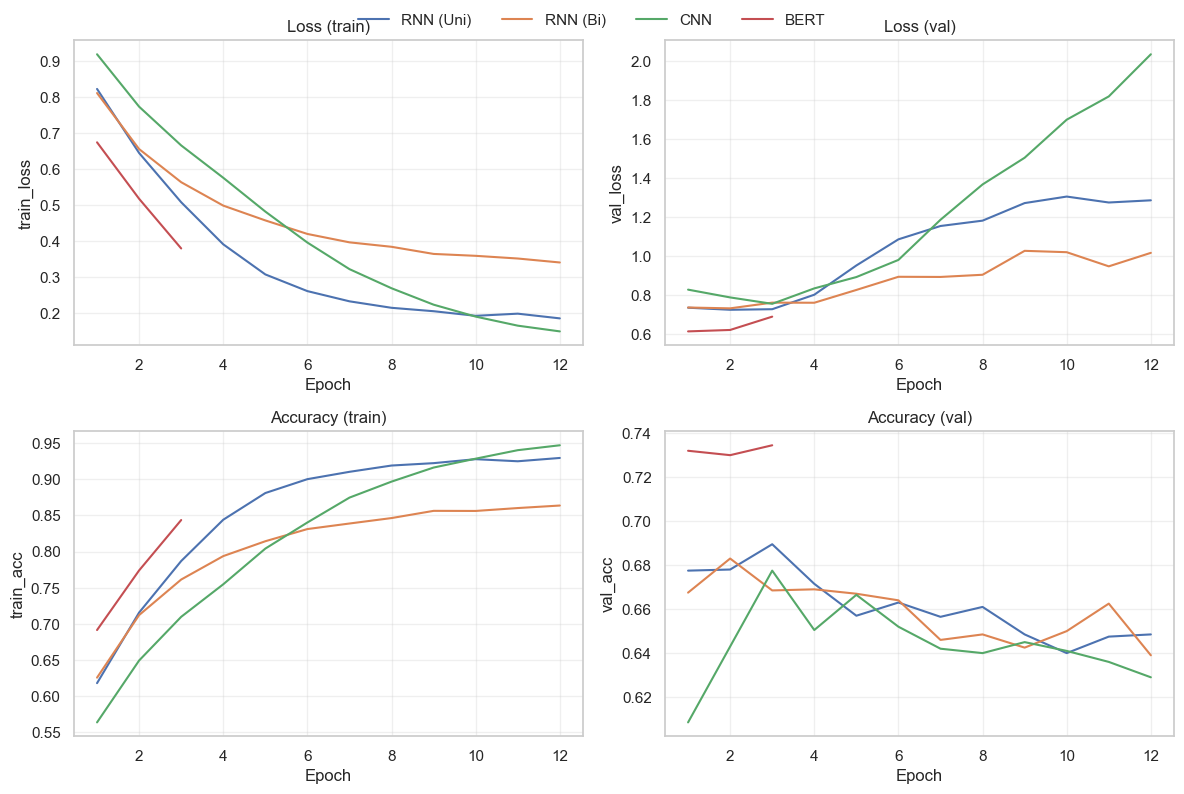

In [32]:
histories = {
    "RNN (Uni)": history_best_rnn,
    "RNN (Bi)": history_best_rnn_bi,
    "CNN": history_best_cnn,
    "BERT": history_bert,
}

metrics = [
    ("train_loss", "Loss (train)"),
    ("val_loss", "Loss (val)"),
    ("train_acc", "Accuracy (train)"),
    ("val_acc", "Accuracy (val)"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, (metric, title) in zip(axes, metrics):
    for name, hist in histories.items():
        if metric not in hist:
            continue
        y = hist[metric]
        x = np.arange(1, len(y) + 1)
        ax.plot(x, y, label=name)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)
    plt.subplots_adjust(top=0.88)

plt.tight_layout()
plt.show()

Val accuracy modele CNN i RNN saturują bardzo wcześnie, transformer z uwagi na złożoność jest tutaj bardziej stabilny - w zasadzie od początku osiąga dobre rezultaty z powodu doskonałej inicjalizacji wag. Zdziwiło mnie accuracy sieci konwolucyjnej, spodziewałem się znacznie niższego od RNN.